In [1]:
from May31_Frank2D_CPU import *

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from constants import rad_to_arcsec, deg_to_rad
from scipy.stats import binned_statistic
from matplotlib.colors import LogNorm

from mpl_toolkits.axes_grid1 import make_axes_locatable

# frank1d utilities
from frank.geometry import SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

__all__ = [
    "Plot",
]

class Plot(object):
    def __init__(self, Frank2D, Geometry):
        self._frank2d = Frank2D
        self._Geometry = Geometry
        self._u_gridded, self._v_gridded = self._frank2d._gridded_data['u'], self._frank2d._gridded_data['v']
        self._vis_gridded, self._weights_gridded = self._frank2d._gridded_data['vis'], self._frank2d._gridded_data['weights']
        self._Nx = Frank2D._Nx
        self._Ny = Frank2D._Ny

        
    def intensity_model(self, title="Frank2D intensity model", deproject = False, zoom = None, fig_size = 6, vmax = 4e10):
        frank2d = self._frank2d
        I = frank2d.sol_intensity
        x_ = frank2d._FT._Xn * rad_to_arcsec
        y_ = frank2d._FT._Yn * rad_to_arcsec
        Nx, Ny = self._Nx, self._Ny
        x, y = x_, y_

        # Deprojection.
        inc_r = self._Geometry._inc * deg_to_rad
        pa_r = self._Geometry._pa * deg_to_rad

        cos_i = np.cos(inc_r)
        cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)
        
        if deproject:
            x = (x_ * cos_pa + y_ * sin_pa) / cos_i
            y = (x_ * -sin_pa + y_ * cos_pa)

        plt.figure(figsize=(fig_size, fig_size))

        X = x.reshape(Ny, Nx)
        Y = y.reshape(Ny, Nx)
        I = I.reshape(Ny, Nx)

        I_flip = np.fliplr(I)
        X_flip = -np.fliplr(X)

        plot = plt.pcolormesh(X_flip, Y, I_flip,
                              cmap='magma', vmin=0, vmax=vmax)
        plt.gca().invert_xaxis()
        cmap = plt.colorbar(plot, shrink=0.8)
        cmap.set_label(r'I [Jy $sr^{-1}$]', size=15)

        plt.title(title)
        plt.xlabel("dRa ['']")
        plt.ylabel("dDec ['']")

        plt.gca().set_aspect(1)  


        xlim = plt.xlim()
        ylim = plt.ylim()
        
        lims = [xlim[1], xlim[0]]

        if zoom is not None:
            plt.xlim(zoom, -zoom)
            plt.ylim(-zoom, zoom)
        else:
            plt.text(
            lims[0] + 0.8 * (lims[1] - lims[0]),  
            lims[0] + 0.1 * (lims[1] - lims[0]),  
            r'  $'+ str(Nx) + '^{2}$ pixels ',
            bbox={'facecolor': 'white', 'pad': 4, 'alpha': 0.8}
        )

        plt.show()


    def visibility_model(self, title="Frank2D visibility model", deproject = False):
            frank2d = self._frank2d
            Nx, Ny = self._Nx, self._Ny

            vis_model = frank2d.sol_visibility.reshape(Nx, Ny)
            
            u, v = frank2d._FT._Un, frank2d._FT._Vn

            u_shifted, v_shifted = np.fft.fftshift(u.reshape(Nx, Ny)), np.fft.fftshift(v.reshape(Nx, Ny))
            vis_shifted = np.fft.fftshift(vis_model)

            if deproject: 
                u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

            plt.pcolormesh(v_shifted,
                           u_shifted,
                           np.log(np.abs(vis_shifted)),
                           cmap="viridis", vmin=-12, vmax=-2)
            plt.xlabel(r'u [ $\lambda$]')
            plt.ylabel(r'v [ $\lambda$]')
            plt.gca().set_aspect('equal') 
            cmap = plt.colorbar(shrink=0.8)
            cmap.set_label(r'V [Jy]', size=15)
            plt.title(r'log|$Vis_{model}$|')
            plt.show()

    def visibility_masked_model(self, title="Frank2D visibility model", deproject = False, threshold = 0.013617754815322927):
            frank2d = self._frank2d
            Nx, Ny = self._Nx, self._Ny

            vis_model = frank2d.sol_visibility.reshape(Nx, Ny)
            
            u, v = frank2d._FT._Un, frank2d._FT._Vn

            u_shifted, v_shifted = np.fft.fftshift(u.reshape(Nx, Ny)), np.fft.fftshift(v.reshape(Nx, Ny))
            vis_shifted = np.fft.fftshift(vis_model)

            if deproject: 
                u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

            abs_vis = np.abs(vis_shifted)
            log_abs_vis = np.log(abs_vis)
        
            mask_high = abs_vis > threshold
            mask_low = ~mask_high
        
            data_low = np.ma.masked_where(mask_high, log_abs_vis)
            data_high = np.ma.masked_where(mask_low, log_abs_vis)
        
            fig, ax = plt.subplots(figsize=(5,5))
            p1 = ax.pcolormesh(v_shifted, u_shifted, data_low, cmap="Greys")#, vmin=-12, vmax=-2)
            p2 = ax.pcolormesh(v_shifted, u_shifted, data_high, cmap="cool")#, vmin=-12, vmax=-2)
        
            ax.set_xlabel(r'u [1e6 $\lambda$]')
            ax.set_ylabel(r'v [1e6 $\lambda$]')
            ax.set_title(r'log |$Vis_{Input}$|')

            ax.set_aspect('equal')
        
            divider = make_axes_locatable(ax)
            cax1 = divider.append_axes("right", size="5%", pad=0.1)
            cax2 = divider.append_axes("right", size="5%", pad=0.7)  # más separada
        
            cbar1 = plt.colorbar(p1, cax=cax1)
            cbar1.set_label(r'$\sigma$ < log|V| [Jy]', size=10)
            
            cbar2 = plt.colorbar(p2, cax=cax2)
            cbar2.set_label(r'$\sigma$ > log|V| [Jy]', size=10)
        
            plt.show()

    def visibility_gridded_input(self, title="Frank2D gridded vis", deproject = False):
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
        
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded, weights_gridded = self._vis_gridded, self._weights_gridded
        
        u_shifted, v_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny)), np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        vis_shifted = np.fft.fftshift(vis_gridded.reshape(Nx, Ny))
        
        if deproject: 
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

        
        plt.pcolormesh(v_shifted,
                       u_shifted,
                       np.log(np.abs(vis_shifted)),
                       cmap="viridis", vmin=-12, vmax=-2)
        plt.xlabel(r'u [1e6 $\lambda$]')
        plt.ylabel(r'v [1e6 $\lambda$]')
        plt.title(r'log |$Vis_{Input}$|')
        cmap = plt.colorbar()
        cmap.set_label(r'V [Jy]', size=15)

    def visibility_masked_input(self, title="Frank2D gridded input", deproject=False, percentil = 90):
        from mpl_toolkits.axes_grid1 import make_axes_locatable
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
    
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded = self._vis_gridded
    
        u_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny))
        v_shifted = np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        vis_shifted = np.fft.fftshift(vis_gridded.reshape(Nx, Ny))
    
        if deproject:
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())
            u_shifted = u_shifted.reshape(Nx, Ny)
            v_shifted = v_shifted.reshape(Nx, Ny)
    
        abs_vis = np.abs(vis_shifted)
        log_abs_vis = np.log(abs_vis)
        threshold = np.percentile(abs_vis, percentil)
        top_values = abs_vis[abs_vis >= threshold]
        min_in_top_percent = np.min(top_values)
        print(min_in_top_percent)
    
        mask_high = abs_vis > min_in_top_percent
        mask_low = ~mask_high
        mask_inner = np.hypot(u_shifted, v_shifted) < 0.9e6
    
        data_low = np.ma.masked_where(mask_high, log_abs_vis)
        data_high = np.ma.masked_where(mask_low, log_abs_vis)
        
        data_high_outer = np.ma.masked_where(mask_low, vis_shifted)*np.ma.masked_where(mask_inner, vis_shifted)
        self._vis_shifted_masked = data_high_outer
    
        fig, ax = plt.subplots(figsize=(5,5))
        p1 = ax.pcolormesh(v_shifted, u_shifted, data_low, cmap="Greys")
        p2 = ax.pcolormesh(v_shifted, u_shifted, data_high, cmap="cool")
        #p3 = ax.pcolormesh(v_shifted, u_shifted, np.log(abs(data_high_outer)), cmap="cool")
        
        ax.set_xlabel(r'u [1e6 $\lambda$]')
        ax.set_ylabel(r'v [1e6 $\lambda$]')
        ax.set_title(r'log |$Vis_{Input}$|')
        ax.set_aspect('equal')
        
        divider = make_axes_locatable(ax)
        
        cax1 = divider.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(p1, cax=cax1)
        cbar1.set_label(r' < '+ str(percentil) +'% log|V| [Jy]', size=10)
        
        cax2 = divider.append_axes("right", size="5%", pad=0.7)  # más separada
        cbar2 = plt.colorbar(p2, cax=cax2)
        cbar2.set_label(r' > '+ str(percentil) +'% log|V|', size=10)
        
        plt.show()

    
    def normalize_vis(self, threshold = 0.013617754815322927, percentil = 92):
        from scipy.ndimage import generic_filter
        from mpl_toolkits.axes_grid1 import make_axes_locatable
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
    
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded = self._vis_gridded
    
        u_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny))
        v_shifted = np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        vis_shifted = np.abs(np.fft.fftshift(vis_gridded.reshape(Nx, Ny)))
        vis_shifted_masked = np.abs(self._vis_shifted_masked)
    
        from scipy.ndimage import convolve
    
        # 1. Máscara de los elementos "malos"
        mask_high = ~self._vis_shifted_masked.mask  # True donde quieres reemplazar
    
        fig, ax = plt.subplots(figsize=(5,5))
        ax.pcolormesh(v_shifted, u_shifted, np.log(vis_shifted_masked), cmap="cool")
    
        vis_shifted_complex = np.fft.fftshift(vis_gridded.reshape(Nx, Ny))
        vis_smoothed_complex = vis_shifted_complex.copy()
        
        rows, cols = np.where(mask_high)
        nrows, ncols = vis_shifted_complex.shape
        
        # Función para obtener mínimo de vecinos
        def neighbor_min(i, j, matrix):
            neighbors = []
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < nrows and 0 <= nj < ncols:
                        val = matrix[ni, nj]
                        if not np.isnan(val):
                            neighbors.append(val)
            return np.mean(neighbors) if neighbors else matrix[i, j]
        
        # Aplicamos mínimo de vecinos a parte real e imaginaria
        for i, j in zip(rows, cols):
            original_val = vis_shifted_complex[i, j]
        
            min_real = neighbor_min(i, j, vis_shifted_complex.real)
            min_imag = neighbor_min(i, j, vis_shifted_complex.imag)
        
            new_val = complex(min_real, min_imag)
            vis_smoothed_complex[i, j] = new_val
    
        abs_vis = abs(vis_smoothed_complex)
        log_abs_vis = np.log(abs_vis)
    
        mask_high = abs_vis > threshold
        mask_low = ~mask_high
        mask_inner = np.hypot(u_shifted, v_shifted) < 0.9e6
    
        data_low = np.ma.masked_where(mask_high, log_abs_vis)
        data_high = np.ma.masked_where(mask_low, log_abs_vis)
    
        fig, ax = plt.subplots(figsize=(5,5))
        p1 = ax.pcolormesh(v_shifted, u_shifted, data_low, cmap="Greys")
        p2 = ax.pcolormesh(v_shifted, u_shifted, data_high, cmap="cool")
    
        ax.set_xlabel(r'u [1e6 $\lambda$]')
        ax.set_ylabel(r'v [1e6 $\lambda$]')
        ax.set_title(r'log |$Vis_{Input}$|')
        ax.set_aspect('equal')
    
        divider = make_axes_locatable(ax)
        cax1 = divider.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(p1, cax=cax1)
        cbar1.set_label(r' $\sigma$ < log|V| [Jy]', size=10)
    
        cax2 = divider.append_axes("right", size="5%", pad=0.7)
        cbar2 = plt.colorbar(p2, cax=cax2)
        cbar2.set_label(r' $\sigma$ > log|V| [Jy]', size=10)
    
        plt.show()
        
        self.vis_smoothed = np.fft.fftshift(vis_smoothed_complex).flatten()

    def weights_gridded_input(self, title="Frank2D gridded weights", deproject = False):
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
        
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded, weights_gridded = self._vis_gridded, self._weights_gridded
        
        u_shifted, v_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny)), np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        weights_shifted = np.fft.fftshift(weights_gridded.reshape(Nx, Ny))
        
        if deproject: 
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

        
        plt.pcolormesh(v_shifted,
                       u_shifted,
                       weights_shifted,
                       vmin=0, vmax=1e1,
                       cmap="viridis")
        plt.xlabel(r'u [1e6 $\lambda$]')
        plt.ylabel(r'v [1e6 $\lambda$]')
        plt.title(r'$Weigths_{Input}$')
        cmap = plt.colorbar()
        cmap.set_label(r'W $[Jy]^2$', size=15)
        


In [100]:
def frank2d_cpu(disk_name, filename, disk_geometry, Rout, N = 100, maxiter=20000, Vis_ = None):
    print("Running: " + disk_name +" ...." + " frank2d model with " + str(N)+ 'x'+str(N)+ " points" )

    inc = disk_geometry['inc']
    pa = disk_geometry['pa']
    dra = disk_geometry['dra']
    ddec = disk_geometry['ddec']
    
    # UVtable
    dir = "../../../data/"
    data_file = dir + filename
    
     # load data
    data = np.load(data_file)
    u, v, Re, Imag, Weights = data['u'], data['v'], data['Re'], data['Im'], data['w']
    Vis = Re + Imag*1j
    
    geom = Geometry(inc, pa, dra, ddec)
    frank2d = Frank2D(N, Rout, geom)
    
    start_time = time.time()
    frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)
    u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']
    if isinstance(Vis_, np.ndarray):
        vis_gridded = Vis_
    else:
        pass
    sol = Frank2D_optimized(N, u_gridded, v_gridded, vis_gridded, weights_gridded, maxiter = maxiter)
    frank2d.sol_visibility = sol
    frank2d.fft()
    
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  ------------------------------------------> TOTAL ALGORITHM TIME = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

    return u_gridded, v_gridded, sol, frank2d, geom, [u, v, Vis, Weights]

In [63]:
u_gridded_AS209, v_gridded_AS209, Vis_model_AS209, FrankObj_AS209, GeomObj_AS209, input_frank_AS209 = frank2d_cpu(
                                            'AS209 1mm',
                                            'uvtables/axisymmetric/uvtable_AS209_continuum.npz',
                                            {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3 },
                                            3,
                                            100
                                            )

Running: AS209 1mm .... frank2d model with 100x100 points
Enforcing Hermitian symmetry...
  --> time = 0.39  min |  23.37 seconds
Setting gridded data...
------> Creating linear operators
  --> time = 0.14  min |  8.38 seconds
---------------------------------
------> Creating sparse system
  --> time = 0.11  min |  6.65 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.24681707851414128
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  246817078.51414126 vs  0.24681707851414128
.... iteration:  1
                        -> actual tol:  19.497044571151307 vs  0.24681707851414128
  --> time = 0.00  min |  0.00 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2ff

In [106]:
# Plots.
Plot_AS209 = Plot(FrankObj_AS209, GeomObj_AS209)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_45538/272951275.py:201: RuntimeWarning: divide by zero encountered in log
  log_abs_vis = np.log(abs_vis)


0.013617754815322927


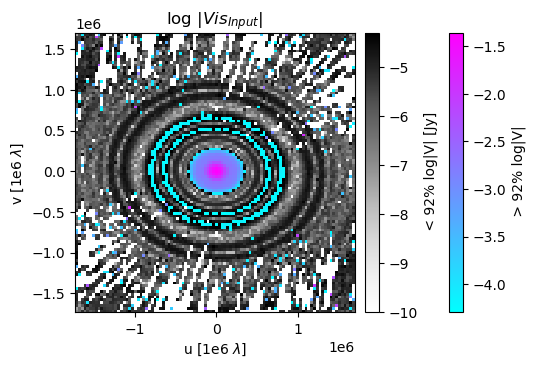

In [107]:
percentil = 92
vis_masked = Plot_AS209.visibility_masked_input(percentil = percentil)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_45538/272951275.py:260: RuntimeWarning: divide by zero encountered in log
  ax.pcolormesh(v_shifted, u_shifted, np.log(vis_shifted_masked), cmap="cool")
/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_45538/272951275.py:293: RuntimeWarning: divide by zero encountered in log
  log_abs_vis = np.log(abs_vis)


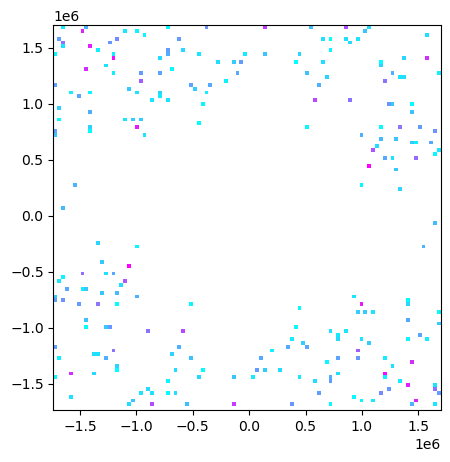

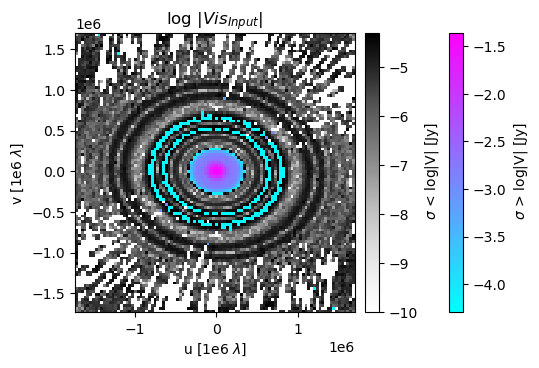

In [108]:
Plot_AS209.normalize_vis(threshold = 0.013617754815322927, percentil = percentil)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_45538/272951275.py:129: RuntimeWarning: divide by zero encountered in log
  log_abs_vis = np.log(abs_vis)


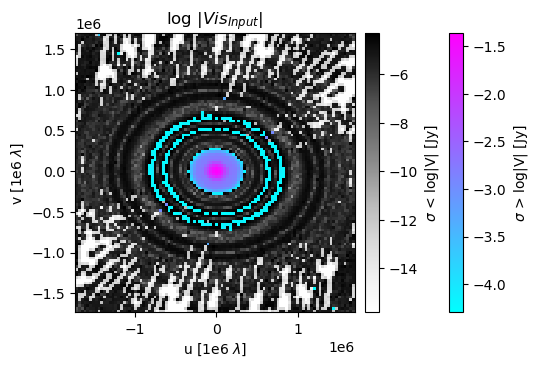

In [109]:
Plot_AS209.visibility_masked_model(threshold = 0.013617754815322927)

In [110]:
Vis_ = Plot_AS209.vis_smoothed

In [111]:
u_gridded_AS209, v_gridded_AS209, Vis_model_AS209, FrankObj_AS209, GeomObj_AS209, input_frank_AS209 = frank2d_cpu(
                                            'AS209 1mm',
                                            'uvtables/axisymmetric/uvtable_AS209_continuum.npz',
                                            {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3 },
                                            3,
                                            100,
                                            Vis_ = Vis_
                                            )

Running: AS209 1mm .... frank2d model with 100x100 points
Enforcing Hermitian symmetry...
  --> time = 0.30  min |  17.85 seconds
Setting gridded data...
------> Creating linear operators
  --> time = 0.14  min |  8.12 seconds
---------------------------------
------> Creating sparse system
  --> time = 0.11  min |  6.79 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.24681707495693478
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  246817074.95693475 vs  0.24681707495693478
.... iteration:  1
                        -> actual tol:  18.78260904747646 vs  0.24681707495693478
  --> time = 0.00  min |  0.00 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft

In [112]:
Plot_AS209_smoothed = Plot(FrankObj_AS209, GeomObj_AS209)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_45538/272951275.py:129: RuntimeWarning: divide by zero encountered in log
  log_abs_vis = np.log(abs_vis)


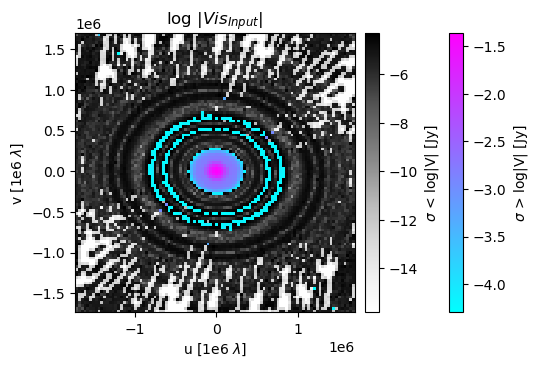

In [113]:
Plot_AS209_smoothed.visibility_masked_model(threshold = 0.013617754815322927)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_45538/272951275.py:104: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


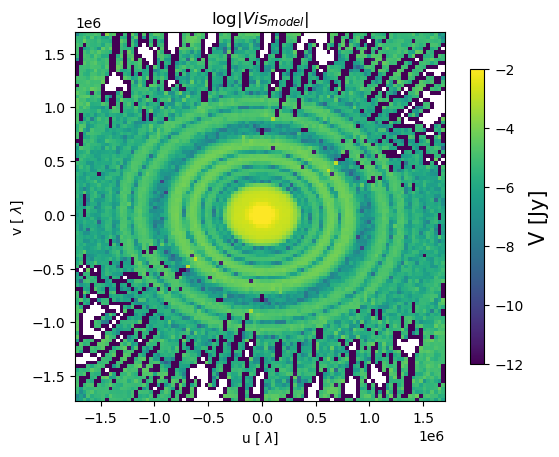

In [117]:
Plot_AS209.visibility_model()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_45538/272951275.py:175: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


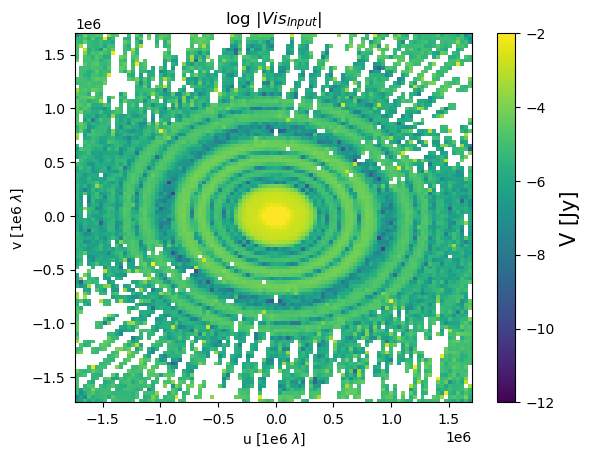

In [115]:
Plot_AS209.visibility_gridded_input()

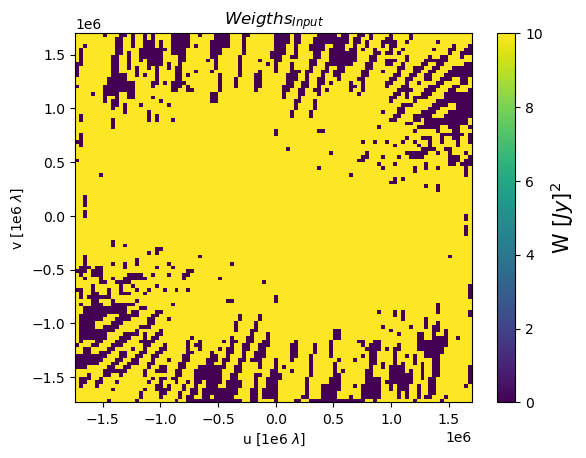

In [116]:
Plot_AS209.weights_gridded_input()

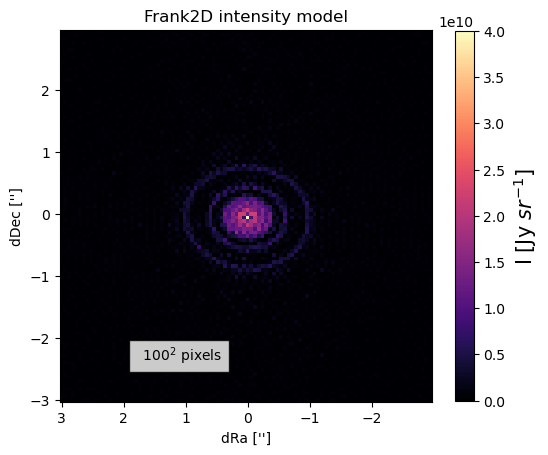

In [10]:
Plot_AS209.intensity_model()